## Q1. Audio Loading and Signal Analysis

C:\Users\Hp\AppData\Local\Temp\ipykernel_34632\2943215331.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, x = wavfile.read("speech.wav")


--- Audio Signal Metadata ---
Sampling Rate:   44100 Hz
Total Samples:   809508
Duration:        18.356 seconds
Max Amplitude:   0.62
Min Amplitude:   -1.00


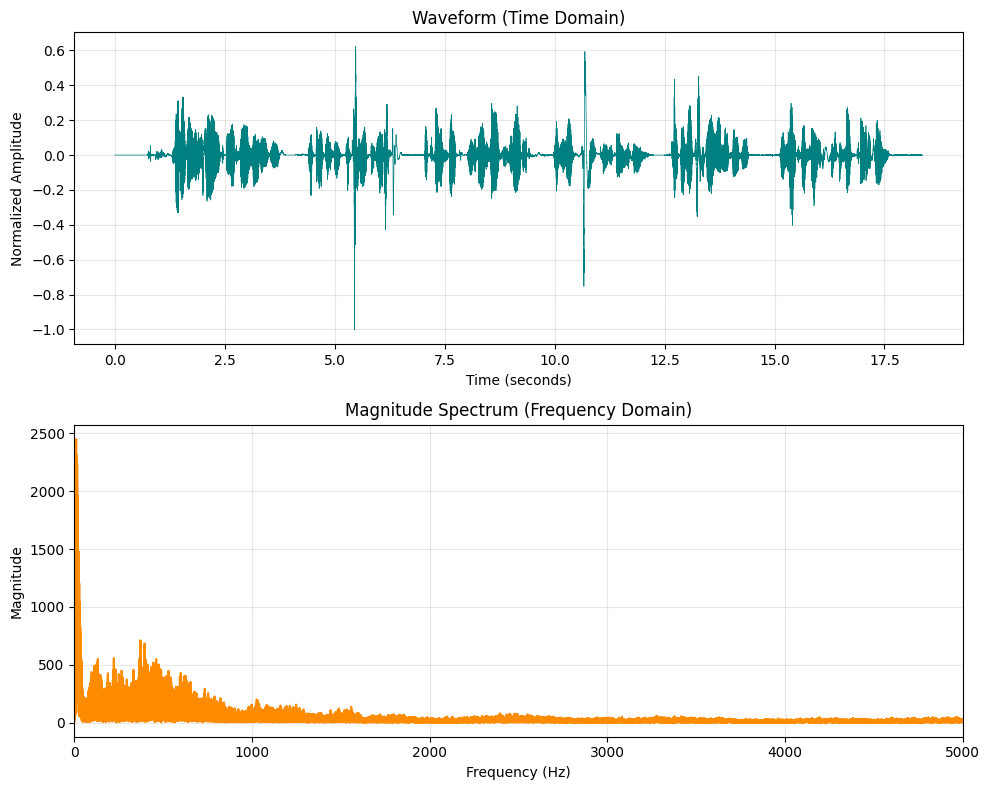

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# Load & normalize
fs, x = wavfile.read("speech.wav")
if x.ndim > 1: x = x[:, 0]
x = x / np.max(np.abs(x))

# Metadata
n = len(x)
duration = n / fs

print("--- Audio Signal Metadata ---")
print(f"Sampling Rate:   {fs} Hz")
print(f"Total Samples:   {n}")
print(f"Duration:        {duration:.3f} seconds")
print(f"Max Amplitude:   {np.max(x):.2f}")
print(f"Min Amplitude:   {np.min(x):.2f}")

# Time axis
t = np.linspace(0, duration, n)

# FFT
fft_out = np.fft.fft(x)
freqs = np.fft.fftfreq(n, 1/fs)
half = n // 2

# Plot
plt.figure(figsize=(10,8))

plt.subplot(2,1,1)
plt.plot(t, x, color='teal', linewidth=0.5)
plt.title("Waveform (Time Domain)")
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Amplitude")
plt.grid(alpha=0.3)

plt.subplot(2,1,2)
plt.plot(freqs[:half], np.abs(fft_out[:half]), color='darkorange')
plt.title("Magnitude Spectrum (Frequency Domain)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 5000)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Q2. Framing and Windowing (From Scratch)  

C:\Users\Hp\AppData\Local\Temp\ipykernel_34632\3489676142.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, x = wavfile.read("speech.wav")


Total Number of Frames: 1835


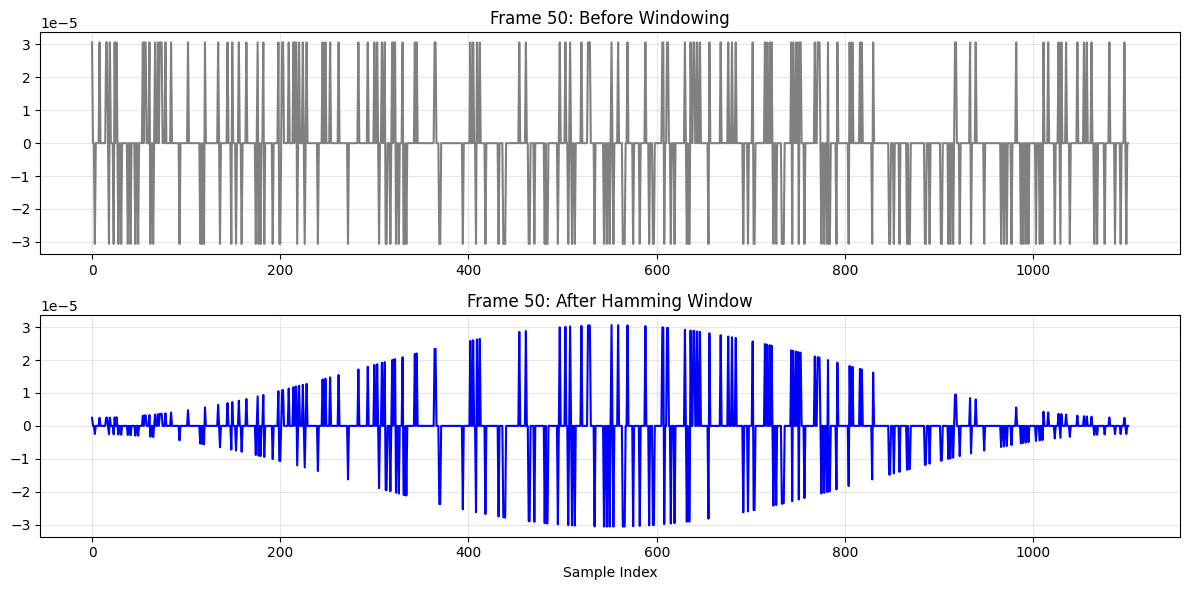

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# Load & normalize
fs, x = wavfile.read("speech.wav")
if x.ndim > 1: x = x[:, 0]
x = x / np.max(np.abs(x))

# Framing params (25ms, 10ms)
frame_len = int(0.025 * fs)
step = int(0.01 * fs)

num_frames = int(np.ceil((len(x) - frame_len) / step)) + 1
pad = np.append(x, np.zeros(num_frames * step + frame_len - len(x)))

# Frames
idx = np.tile(np.arange(frame_len), (num_frames, 1)) + \
      np.tile(np.arange(0, num_frames * step, step), (frame_len, 1)).T
frames = pad[idx.astype(int)]

# Hamming window
windowed = frames * np.hamming(frame_len)

print("Total Number of Frames:", num_frames)

# Plot sample frame
i = 50
plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
plt.plot(frames[i], color='gray')
plt.title(f"Frame {i}: Before Windowing")
plt.grid(alpha=0.3)

plt.subplot(2,1,2)
plt.plot(windowed[i], color='blue')
plt.title(f"Frame {i}: After Hamming Window")
plt.xlabel("Sample Index")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Q3. STFT and Spectrogram Generation  

C:\Users\Hp\AppData\Local\Temp\ipykernel_34632\1859574590.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, x = wavfile.read("speech.wav")


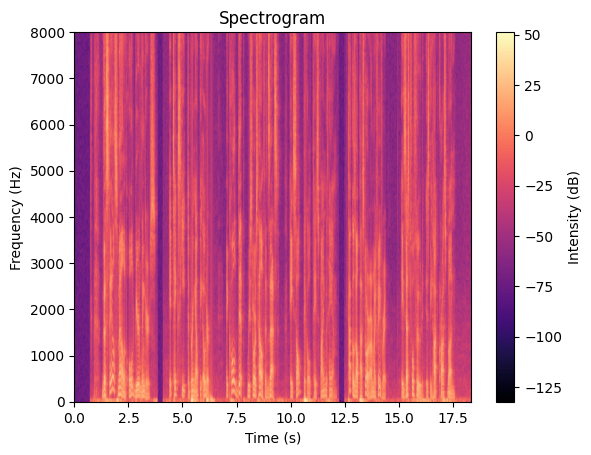

Application: Speaker Identification (formant patterns).


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# Load & normalize
fs, x = wavfile.read("speech.wav")
if x.ndim > 1: x = x[:,0]
x = x / np.max(np.abs(x))

# Parameters
frame_len = int(0.025 * fs)
step = int(0.01 * fs)
window = np.hamming(frame_len)

# Framing
num_frames = int(np.floor((len(x) - frame_len) / step)) + 1
frames = np.array([x[i*step:i*step+frame_len] * window for i in range(num_frames)])

# STFT
stft = np.abs(np.fft.rfft(frames))

# dB
spec_db = 20 * np.log10(stft + 1e-10)

# Plot
plt.imshow(spec_db.T, origin='lower', aspect='auto',
           extent=[0, len(x)/fs, 0, fs/2], cmap='magma')
plt.colorbar(label='Intensity (dB)')
plt.title("Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.ylim(0, 8000)
plt.show()

# Application
print("Application: Speaker Identification (formant patterns).")

## Q4. MFCC Extraction

C:\Users\Hp\AppData\Local\Temp\ipykernel_34632\4019874581.py:7: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, signal = wavfile.read("speech.wav")


MFCC shape: (1834, 13)


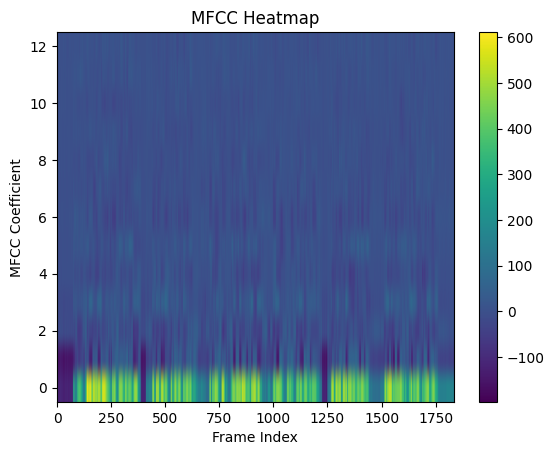

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fftpack import dct

# Load audio
fs, signal = wavfile.read("speech.wav")
if signal.ndim == 2:
    signal = signal[:, 0]
signal = signal.astype(float)

# Pre-emphasis
signal = np.append(signal[0], signal[1:] - 0.97 * signal[:-1])

# Framing
frame_len = int(0.025 * fs)
frame_step = int(0.01 * fs)

num_frames = int(np.ceil((len(signal) - frame_len) / frame_step))
pad_len = num_frames * frame_step + frame_len
signal = np.append(signal, np.zeros(pad_len - len(signal)))

indices = np.tile(np.arange(frame_len), (num_frames, 1)) + \
          np.tile(np.arange(0, num_frames * frame_step, frame_step), (frame_len, 1)).T

frames = signal[indices.astype(int)]

# Windowing
frames *= np.hamming(frame_len)

# FFT & Power Spectrum
NFFT = 512
pow_frames = (np.abs(np.fft.rfft(frames, NFFT)) ** 2) / NFFT

# Mel Filterbank
nfilt = 26
mel = np.linspace(0, 2595*np.log10(1 + fs/2/700), nfilt+2)
hz = 700*(10**(mel/2595)-1)
bins = np.floor((NFFT+1)*hz/fs).astype(int)

fbank = np.zeros((nfilt, NFFT//2 + 1))
for m in range(1, nfilt+1):
    fbank[m-1, bins[m-1]:bins[m]] = np.linspace(0,1,bins[m]-bins[m-1])
    fbank[m-1, bins[m]:bins[m+1]] = np.linspace(1,0,bins[m+1]-bins[m])

filter_banks = np.dot(pow_frames, fbank.T)
filter_banks = 20*np.log10(np.maximum(filter_banks, np.finfo(float).eps))

# MFCC
mfcc = dct(filter_banks, type=2, axis=1, norm='ortho')[:, :13]

print("MFCC shape:", mfcc.shape)

# Plot
plt.imshow(mfcc.T, aspect='auto', origin='lower')
plt.title("MFCC Heatmap")
plt.xlabel("Frame Index")
plt.ylabel("MFCC Coefficient")
plt.colorbar()
plt.show()

## Q5. Pitch Detection Using Autocorrelation  

C:\Users\Hp\AppData\Local\Temp\ipykernel_34632\1806023692.py:9: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, signal = wavfile.read(audio_path)


Pitch contour extracted.


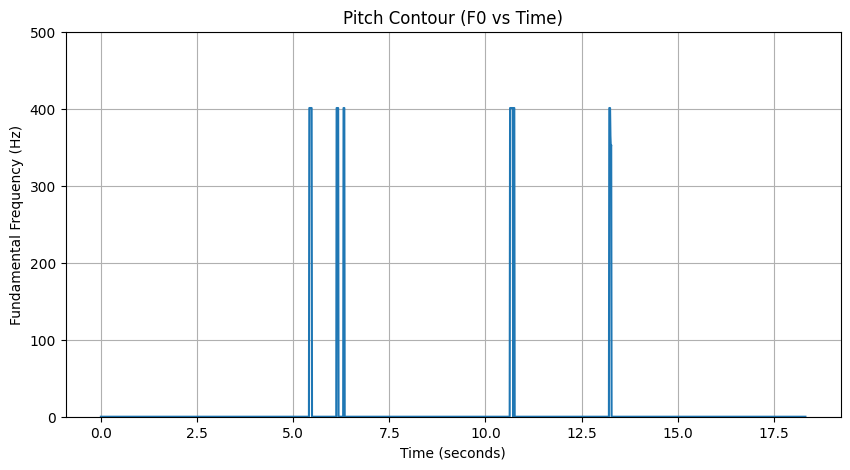

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# =========================
# 1. Load Audio
# =========================
audio_path = r"D:\Lab Test\speech.wav"
sample_rate, signal = wavfile.read(audio_path)

if len(signal.shape) == 2:
    signal = signal[:, 0]

signal = signal.astype(float)

# =========================
# 2. Framing
# =========================
frame_size = 0.03   # 30 ms
frame_stride = 0.01 # 10 ms

frame_length = int(frame_size * sample_rate)
frame_step = int(frame_stride * sample_rate)

num_frames = int(np.ceil(float(len(signal) - frame_length) / frame_step))

frames = []
for i in range(num_frames):
    start = i * frame_step
    end = start + frame_length
    frames.append(signal[start:end])

frames = np.array(frames)

# =========================
# 3. Energy Calculation (for V/UV)
# =========================
energy = np.sum(frames ** 2, axis=1)

# Energy threshold (simple method)
energy_threshold = 0.1 * np.max(energy)

# =========================
# 4. Autocorrelation Pitch Estimation
# =========================
f0 = np.zeros(num_frames)

min_f0 = 50    # Minimum pitch (Hz)
max_f0 = 400   # Maximum pitch (Hz)

min_lag = int(sample_rate / max_f0)
max_lag = int(sample_rate / min_f0)

for i in range(num_frames):

    if energy[i] < energy_threshold:
        f0[i] = 0   # Unvoiced frame
        continue

    frame = frames[i]
    frame = frame - np.mean(frame)

    autocorr = np.correlate(frame, frame, mode='full')
    autocorr = autocorr[len(autocorr)//2:]

    # Search for peak in valid pitch range
    autocorr_range = autocorr[min_lag:max_lag]
    peak_index = np.argmax(autocorr_range)
    lag = peak_index + min_lag

    f0[i] = sample_rate / lag

print("Pitch contour extracted.")

time_axis = np.arange(num_frames) * frame_stride

plt.figure(figsize=(10, 5))
plt.plot(time_axis, f0)
plt.xlabel("Time (seconds)")
plt.ylabel("Fundamental Frequency (Hz)")
plt.title("Pitch Contour (F0 vs Time)")
plt.ylim(0, 500)
plt.grid()
plt.show()


## Q6. Speech Enhancement by Spectral Subtraction  

In [7]:
import numpy as np
import librosa
import soundfile as sf

# =========================
# 1. Load Clean Speech
# =========================
speech, sr = librosa.load('speech.wav', sr=None)

# =========================
# 2. Add White Noise (10 dB SNR)
# =========================
def add_noise(signal, snr_db):
    noise = np.random.randn(len(signal))

    signal_power = np.mean(signal**2)
    noise_power = np.mean(noise**2)

    noise = noise * np.sqrt(signal_power / (noise_power * 10**(snr_db/10)))

    noisy_signal = signal + noise
    return noisy_signal, noise

noisy, noise = add_noise(speech, 10)

# =========================
# 3. Spectral Subtraction
# =========================
def spectral_subtraction(noisy_signal, noise_signal, frame_size=1024, hop_size=512):

    window = np.hamming(frame_size)

    enhanced_signal = np.zeros(len(noisy_signal))
    noise_frames = []

    # Estimate noise spectrum (from noise signal)
    for i in range(0, len(noise_signal) - frame_size, hop_size):
        frame = noise_signal[i:i+frame_size] * window
        spectrum = np.fft.fft(frame)
        noise_frames.append(np.abs(spectrum))

    noise_spectrum = np.mean(noise_frames, axis=0)

    # Process noisy signal
    for i in range(0, len(noisy_signal) - frame_size, hop_size):
        frame = noisy_signal[i:i+frame_size] * window

        spectrum = np.fft.fft(frame)
        magnitude = np.abs(spectrum)
        phase = np.angle(spectrum)

        # Spectral subtraction
        clean_mag = magnitude - noise_spectrum
        clean_mag = np.maximum(clean_mag, 0)

        # Reconstruct
        clean_spectrum = clean_mag * np.exp(1j * phase)
        clean_frame = np.real(np.fft.ifft(clean_spectrum))

        enhanced_signal[i:i+frame_size] += clean_frame

    return enhanced_signal

enhanced = spectral_subtraction(noisy, noise)

# =========================
# 4. SNR Calculation
# =========================
def compute_snr(clean, processed):
    noise = clean - processed
    return 10 * np.log10(np.sum(clean**2) / np.sum(noise**2))

snr_before = compute_snr(speech, noisy)
snr_after = compute_snr(speech, enhanced)

# =========================
# 5. Save Output Files
# =========================
sf.write('noisy.wav', noisy, sr)
sf.write('enhanced.wav', enhanced, sr)

# =========================
# 6. Print Results
# =========================
print("SNR Before Enhancement: {:.2f} dB".format(snr_before))
print("SNR After Enhancement: {:.2f} dB".format(snr_after))
print("SNR Improvement: {:.2f} dB".format(snr_after - snr_before))

SNR Before Enhancement: 10.00 dB
SNR After Enhancement: 16.21 dB
SNR Improvement: 6.21 dB


## Q7. DTW-Based Isolated Word Recognition

Total Train Samples: 60
Total Test Samples: 40
Processed Test Sample 1/40
Processed Test Sample 2/40
Processed Test Sample 3/40
Processed Test Sample 4/40
Processed Test Sample 5/40
Processed Test Sample 6/40
Processed Test Sample 7/40
Processed Test Sample 8/40
Processed Test Sample 9/40
Processed Test Sample 10/40
Processed Test Sample 11/40
Processed Test Sample 12/40
Processed Test Sample 13/40
Processed Test Sample 14/40
Processed Test Sample 15/40
Processed Test Sample 16/40
Processed Test Sample 17/40
Processed Test Sample 18/40
Processed Test Sample 19/40
Processed Test Sample 20/40
Processed Test Sample 21/40
Processed Test Sample 22/40
Processed Test Sample 23/40
Processed Test Sample 24/40
Processed Test Sample 25/40
Processed Test Sample 26/40
Processed Test Sample 27/40
Processed Test Sample 28/40
Processed Test Sample 29/40
Processed Test Sample 30/40
Processed Test Sample 31/40
Processed Test Sample 32/40
Processed Test Sample 33/40
Processed Test Sample 34/40
Processed 

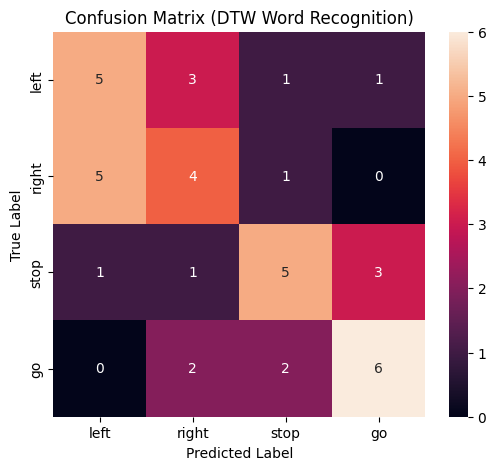

In [11]:
import os
import numpy as np
import librosa
from scipy.spatial.distance import cdist
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# Dataset Path
# =========================
DATASET_PATH = r"D:\Lab Test\mini_speech_commands\mini_speech_commands"
WORDS = ["left", "right", "stop", "go"]

# =========================
# Parameters (LIMITED DATA)
# =========================
FILES_PER_WORD = 40   # total files per word
TRAIN_PER_WORD = 15   # training samples
TEST_PER_WORD = 10    # testing samples

# =========================
# MFCC Extraction
# =========================
def extract_mfcc(file):
    y, sr = librosa.load(file, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    return mfcc.T

# =========================
# DTW Distance
# =========================
def dtw_distance(x, y):
    D = cdist(x, y)
    cost = np.zeros(D.shape)
    cost[0, 0] = D[0, 0]

    for i in range(1, D.shape[0]):
        cost[i, 0] = D[i, 0] + cost[i-1, 0]

    for j in range(1, D.shape[1]):
        cost[0, j] = D[0, j] + cost[0, j-1]

    for i in range(1, D.shape[0]):
        for j in range(1, D.shape[1]):
            cost[i, j] = D[i, j] + min(
                cost[i-1, j],
                cost[i, j-1],
                cost[i-1, j-1]
            )

    return cost[-1, -1]

# =========================
# Prepare Dataset
# =========================
train_data = []
train_labels = []
test_data = []
test_labels = []

for word in WORDS:
    folder = os.path.join(DATASET_PATH, word)
    files = os.listdir(folder)[:FILES_PER_WORD]
    np.random.shuffle(files)

    for i, file in enumerate(files):
        path = os.path.join(folder, file)
        mfcc = extract_mfcc(path)

        if i < TRAIN_PER_WORD:
            train_data.append(mfcc)
            train_labels.append(word)

        elif i < TRAIN_PER_WORD + TEST_PER_WORD:
            test_data.append(mfcc)
            test_labels.append(word)

print("Total Train Samples:", len(train_data))
print("Total Test Samples:", len(test_data))

# =========================
# Prediction
# =========================
predictions = []

for idx, test_sample in enumerate(test_data):
    distances = [
        dtw_distance(test_sample, train_sample)
        for train_sample in train_data
    ]
    predicted_label = train_labels[np.argmin(distances)]
    predictions.append(predicted_label)

    print(f"Processed Test Sample {idx+1}/{len(test_data)}")

# =========================
# Evaluation
# =========================
accuracy = accuracy_score(test_labels, predictions)
print("\nFinal Accuracy:", accuracy)

cm = confusion_matrix(test_labels, predictions, labels=WORDS)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=WORDS,
            yticklabels=WORDS)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (DTW Word Recognition)")
plt.show()

### self Dataset 

Recognition Accuracy: 25.00%


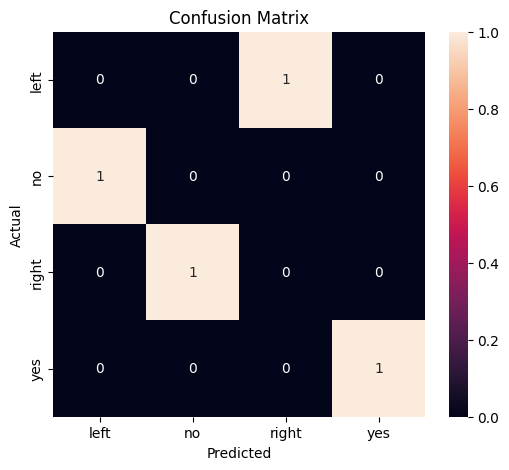

In [ ]:
import os
from pathlib import Path
import numpy as np
import librosa
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# MFCC Extraction
# -------------------------
def extract_mfcc(file_path, n_mfcc=13):
    signal, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)
    return mfcc.T   # shape: (frames, 13)


def dtw_distance(x, y):
    N, M = len(x), len(y)
    dtw = np.zeros((N + 1, M + 1)) + np.inf
    dtw[0, 0] = 0

    for i in range(1, N + 1):
        for j in range(1, M + 1):
            cost = np.linalg.norm(x[i - 1] - y[j - 1])
            dtw[i, j] = cost + min(
                dtw[i - 1, j],      # insertion
                dtw[i, j - 1],      # deletion
                dtw[i - 1, j - 1]   # match
            )

    return dtw[N, M]


# -------------------------
# Dataset path - use correct directory structure
# -------------------------
base_dir = Path(r"D:\Lab Test\Dataset")
train_path = base_dir / "trian"
test_path = base_dir / "test"

words = ["left", "no", "right", "yes"]

if not train_path.exists():
    raise FileNotFoundError(f"Train folder not found: {train_path}")
if not test_path.exists():
    raise FileNotFoundError(f"Test folder not found: {test_path}")

train_features = {}
for word in words:
    train_features[word] = []
    folder = train_path / word

    if not folder.exists():
        raise FileNotFoundError(f"Missing word folder in train set: {folder}")

    for file in os.listdir(folder):
        if file.lower().endswith(".wav"):
            mfcc = extract_mfcc(folder / file)
            train_features[word].append(mfcc)

y_true = []
y_pred = []

for word in words:
    folder = test_path / word

    if not folder.exists():
        raise FileNotFoundError(f"Missing word folder in test set: {folder}")

    for file in os.listdir(folder):
        if not file.lower().endswith(".wav"):
            continue

        test_mfcc = extract_mfcc(folder / file)

        min_dist = float("inf")
        predicted_word = None

        for train_word in words:
            for train_mfcc in train_features[train_word]:
                dist = dtw_distance(test_mfcc, train_mfcc)

                if dist < min_dist:
                    min_dist = dist
                    predicted_word = train_word

        y_true.append(word)
        y_pred.append(predicted_word)

accuracy = np.mean(np.array(y_true) == np.array(y_pred))
print("Recognition Accuracy: {:.2f}%".format(accuracy * 100))

cm = confusion_matrix(y_true, y_pred, labels=words)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=words, yticklabels=words)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Q8. Voice Activity Detection (VAD) and Segmentation  

C:\Users\Hp\AppData\Local\Temp\ipykernel_34632\2918946810.py:9: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, signal = wavfile.read("speech.wav")


Energy & ZCR computed.


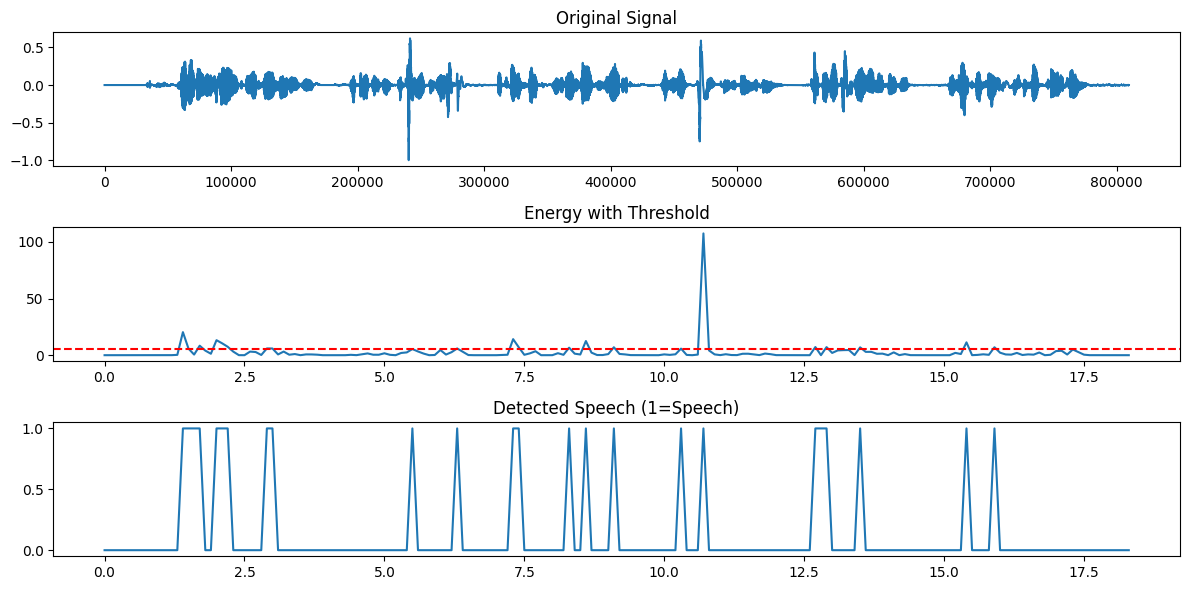

✅ Speech segments saved successfully!


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import os

# =========================
# 1. Load + Normalize
# =========================
fs, signal = wavfile.read("speech.wav")

if signal.ndim == 2:  # stereo → mono
    signal = signal[:, 0]

signal = signal.astype(float)
signal /= np.max(np.abs(signal))

# =========================
# 2. Framing
# =========================
frame_size = 0.025
frame_stride = 0.1

frame_length = int(frame_size * fs)
frame_step = int(frame_stride * fs)

frames = np.array([
    signal[i:i+frame_length]
    for i in range(0, len(signal)-frame_length, frame_step)
])

# =========================
# 3. Energy + ZCR
# =========================
energy = np.sum(frames**2, axis=1)

zcr = np.sum(
    np.abs(np.diff(np.sign(frames), axis=1)),
    axis=1
) / (2 * frame_length)

print("Energy & ZCR computed.")

# =========================
# 4. Threshold
# =========================
energy_threshold = 0.05 * np.max(energy)
speech_frames = (energy > energy_threshold).astype(int)

# Smooth
speech_frames[1:-1] = np.where(
    (speech_frames[:-2] == 1) & (speech_frames[2:] == 1),
    1,
    speech_frames[1:-1]
)

# =========================
# 5. Plot
# =========================
time_axis = np.arange(len(frames)) * frame_stride

plt.figure(figsize=(12,6))

plt.subplot(3,1,1)
plt.plot(signal)
plt.title("Original Signal")

plt.subplot(3,1,2)
plt.plot(time_axis, energy)
plt.axhline(y=energy_threshold, color='r', linestyle='--')
plt.title("Energy with Threshold")

plt.subplot(3,1,3)
plt.plot(time_axis, speech_frames)
plt.title("Detected Speech (1=Speech)")

plt.tight_layout()
plt.show()

# =========================
# 6. Save Segments
# =========================
os.makedirs("segments", exist_ok=True)

segment, count = [], 0

for i, flag in enumerate(speech_frames):
    start = i * frame_step
    end = start + frame_length

    if flag:
        segment.extend(signal[start:end])
    elif segment:
        seg = (np.array(segment) * 32767).astype(np.int16)
        wavfile.write(f"segments/segment_{count}.wav", fs, seg)
        count += 1
        segment = []

# last segment
if segment:
    seg = (np.array(segment) * 32767).astype(np.int16)
    wavfile.write(f"segments/segment_{count}.wav", fs, seg)

print("✅ Speech segments saved successfully!")

## Q9. Speaker Identification using Simple Embedding  

In [ ]:
# =========================
# Dataset Path
# =========================
DATASET_PATH = r"D:\Lab Test\Dataset\trian"
WORDS = ["left", "no", "right", "yes"]

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'D:\\Lab Test\\Dataset\\left'